# END OF PHASE 1 PROJECT

## Introduction

# Business Problem

Company XYZ is looking to venture into new enterprises as it expands it's portfolio. They have a keen <brk> interest in the aviation industry but would like to have further research done as they are not knowledgeable <brk> with the industry. Specifically, they are interested in knowing the potential risks in air crafts before they embark in this new business venture. 
The stakeholders of the company obviously recognize the importance of making data driven decisions.

In the quest to answer the Company's questions on the potential risks in air crafts, we need to do an explorative data analysis on current data about air crafts incidences. For this we will use data from the National Transportation Safety Board (NTSB) that includes all aviation accident data from 1962 to 2023 about civil aviation accidents and selected incidents in the United States and international waters. The files are **AviationData.csv** and **USState_Codes.csv**

So, what questions do we seek to answer to establish the low risk air crafts that the head of aviation at Company XYZ will use to make a decision when purchasing air crafts?
1. Which air crafts are most common in accidents? 
2. Which air crafts have been involved in few accidents? 
3. What is the trend in air craft accidents over the years?

## Loading the data

In [34]:
# load the libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
# load the file
data_df = pd.read_csv("AviationData.csv", encoding="ISO-8859-1", low_memory=False)
# loading only the first 5 rows
data_df.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,year
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN,1948
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996,1962
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007,1974
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000,1977
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980,1979


In [36]:
codes_df = pd.read_csv("USState_Codes.csv")

codes_df.head()

,US_State,Abbreviation
0,Alabama,AL
1,Alaska,AK
2,Arizona,AZ
3,Arkansas,AR
4,California,CA


## Data Characteristics 

In [37]:
# checking the data type
data_df.dtypes

Event.Id                   object
Investigation.Type         object
Accident.Number            object
Event.Date                 object
Location                   object
Country                    object
Latitude                   object
Longitude                  object
Airport.Code               object
Airport.Name               object
Injury.Severity            object
Aircraft.damage            object
Aircraft.Category          object
Registration.Number        object
Make                       object
Model                      object
Amateur.Built              object
Number.of.Engines         float64
Engine.Type                object
FAR.Description            object
Schedule                   object
Purpose.of.flight           int64
Air.carrier                object
Total.Fatal.Injuries      float64
Total.Serious.Injuries    float64
Total.Minor.Injuries      float64
Total.Uninjured           float64
Weather.Condition          object
Broad.phase.of.flight      object
Report.Status 

In [38]:
# checking the structure
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      88889 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  Make                    88889 non-null

In [39]:
# check for missing values
data_df.isnull().sum()

Event.Id                      0
Investigation.Type            0
Accident.Number               0
Event.Date                    0
Location                     52
Country                     226
Latitude                  54507
Longitude                 54516
Airport.Code              38757
Airport.Name              36185
Injury.Severity            1000
Aircraft.damage            3194
Aircraft.Category         56602
Registration.Number        1382
Make                          0
Model                         0
Amateur.Built               102
Number.of.Engines          6084
Engine.Type                   0
FAR.Description           56866
Schedule                  76307
Purpose.of.flight             0
Air.carrier               72241
Total.Fatal.Injuries          0
Total.Serious.Injuries    12510
Total.Minor.Injuries      11933
Total.Uninjured            5912
Weather.Condition          4492
Broad.phase.of.flight     27165
Report.Status              6384
Publication.Date          13771
year    

In [40]:
# check for the percentage of missing data rounded off to 2 decimal places
percentage_missing = np.round(((data_df.isnull().sum() / len(data_df)) * 100), 2)
percentage_missing.sort_values(ascending=False)


Schedule                  85.85
Air.carrier               81.27
FAR.Description           63.97
Aircraft.Category         63.68
Longitude                 61.33
Latitude                  61.32
Airport.Code              43.60
Airport.Name              40.71
Broad.phase.of.flight     30.56
Publication.Date          15.49
Total.Serious.Injuries    14.07
Total.Minor.Injuries      13.42
Report.Status              7.18
Number.of.Engines          6.84
Total.Uninjured            6.65
Weather.Condition          5.05
Aircraft.damage            3.59
Registration.Number        1.55
Injury.Severity            1.12
Country                    0.25
Amateur.Built              0.11
Location                   0.06
Event.Date                 0.00
Accident.Number            0.00
Model                      0.00
Make                       0.00
Investigation.Type         0.00
Event.Id                   0.00
Total.Fatal.Injuries       0.00
Purpose.of.flight          0.00
Engine.Type                0.00
year    

In [41]:
# Check for duplicated data
data_df.duplicated().any

<bound method Series.any of 0        False
1        False
2        False
3        False
4        False
         ...  
88884    False
88885    False
88886    False
88887    False
88888    False
Length: 88889, dtype: bool>

From the above characteristics, we have columns which are highly missing data and some of these columns are crucial for our analysis. Let us now handle the columns with missing data.

Also, from the data_df, the 'Make column' has an issue with repetition of aircraft makes due to capitalization issues. For example there is 'cessna' and 'CESSNA' which refer to the same. To sort this out we shall convert all the values to lowercase for consistency.

In [42]:
data_df['Make'] = data_df['Make'].str.lower()
data_df['Make'].head(5)

0     stinson
1       piper
2      cessna
3    rockwell
4      cessna
Name: Make, dtype: object

## Data Analysis

We now have an idea of what the data looks like and established that there are missing values in majority of the columns. Though, it is worth noting that the categorical columns have few data missing.
Lets now answer our three questions.

**1. Which air crafts are most commonly involved in accidents from the data frame data_df?**

For this analysis we will analyze using 'Make', 'Model', 'Engine Type' and 'Number of Engines'. These attributes will be important in making a decision about safer air crafts characteristics.

The missing values in these columns are all below 8% therefore will consider filling in the missing values. To avoid bias we shall fill in the missing data with 'Uknown'.


In [43]:

data_df.loc[:,"Make"] = data_df["Make"].fillna("Uknown")
data_df.loc[:,"Model"] = data_df["Model"].fillna("Uknown")
data_df.loc[:,"Engine.Type"] = data_df["Engine.Type"].fillna("Uknown")
# convert column to string type
data_df["Number.of.Engines"] = data_df["Number.of.Engines"].astype(str).fillna("Unknown")


In [44]:
missing_values = data_df[["Make", "Model", "Engine.Type", "Number.of.Engines"]].isnull().sum()
assert missing_values.sum() == 0, f"Some columns still have missing values:\n{missing_values}"

print(missing_values)

Make                 0
Model                0
Engine.Type          0
Number.of.Engines    0
dtype: int64


In [45]:
# Top 5 aircraft makes and models that are involved in most accident 
top_5_makes = data_df["Make"].value_counts().head(5)
top_5_models = data_df["Model"].value_counts().head(5)
print(top_5_makes)
print(top_5_models)

Make
cessna    27149
piper     14870
beech      5372
boeing     2745
bell       2722
Name: count, dtype: int64
Model
152          2367
172          1756
172N         1164
PA-28-140     932
150           829
Name: count, dtype: int64


Now lets do a clear picture through visuals by plotting a bar chart for each and do a comparison.

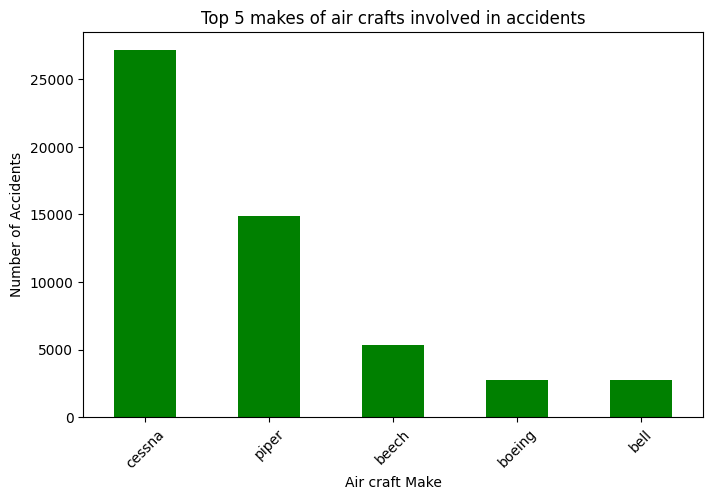

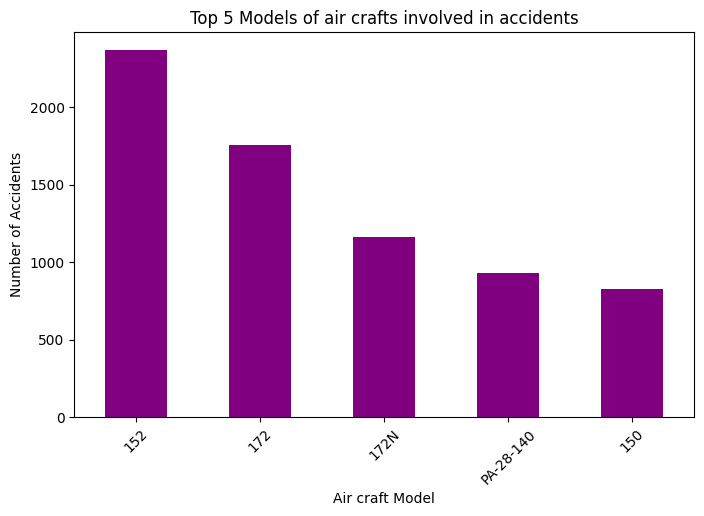

In [46]:
# plot for makes
plt.figure(figsize=(8, 5))
top_5_makes.plot(kind="bar", color='green')
plt.title("Top 5 makes of air crafts involved in accidents")
plt.xlabel("Air craft Make")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)

# plot for models
plt.figure(figsize=(8, 5))
top_5_models.plot(kind="bar", color="purple")
plt.title("Top 5 Models of air crafts involved in accidents")
plt.xlabel("Air craft Model")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)

plt.show()

**2. The makes and models of air crafts that have been involved in the fewest accidents?**

In [47]:
make_model_counts = data_df.groupby(["Make", "Model"]).size()
fewest_accidents = make_model_counts.sort_values(ascending=True).head(10)
print(fewest_accidents)

Make                    Model       
zlin                    Z143            1
                        Z-42M           1
                        Savage          1
zivko aeronautics inc.  Edge 540-T      1
a. le francois          RANS S-7        1
a. h. gettings          GLASSAIR SH2    1
a pair of jacks         RV-6A           1
85 manista              KB-2            1
781569 inc              FX 210          1
777                     FF2             1
dtype: int64


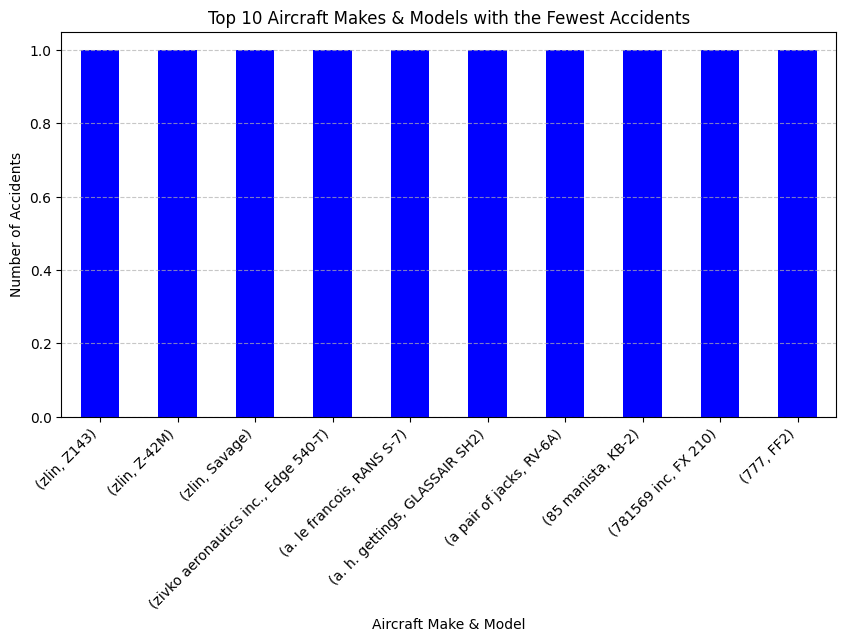

In [48]:


# Plot a bar chart
plt.figure(figsize=(10, 5))
fewest_accidents.plot(kind="bar", color="blue")

# Customize the plot
plt.title("Top 10 Aircraft Makes & Models with the Fewest Accidents")
plt.ylabel("Number of Accidents")
plt.xlabel("Aircraft Make & Model")
plt.xticks(rotation=45, ha="right")  # Rotate labels for readability
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()


Lets calculate the fatal injuries per make of the air craft. The column 'Total.Fatal.Injuries' has missing values at 12.83%. We shall fill in the missing values using the mean.

In [49]:
fatal_inj_mean = round(data_df["Total.Fatal.Injuries"].mean()) # rounded off to a whole number
# fill in missing values with the mean
data_df["Total.Fatal.Injuries"].fillna(fatal_inj_mean, inplace=True)
print(data_df["Total.Fatal.Injuries"].isnull().sum())


0


C:\Users\njeri\AppData\Local\Temp\ipykernel_5988\1276318124.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df["Total.Fatal.Injuries"].fillna(fatal_inj_mean, inplace=True)


In [50]:
fatal_injuries_per_make = data_df.groupby("Make")["Total.Fatal.Injuries"].sum().sort_values(ascending=False)
fatal_injuries_per_make

Make
cessna                      12978.0
boeing                       9223.0
piper                        8364.0
beech                        4361.0
bell                         1702.0
                             ...   
jim price                       0.0
jim green                       0.0
jim elliott                     0.0
jim braddock                    0.0
zs delta-bielsko wroclaw        0.0
Name: Total.Fatal.Injuries, Length: 7588, dtype: float64

From the above analysis, we see that the top 5 makes of air crafts still feature with the highest total fatal injuries.

Lets also find out if there is a relation between 'Purpose.of.flight' and 'accident'. This could give us an insight if a certain purpose of flight tends to have more accidents than others. For example 'instructional' purpose tends to have the most accidents.

In [51]:
data_df['Purpose.of.flight'] = data_df['Purpose.of.flight'].astype('category').cat.codes

purpose_accident_corr = data_df[["Purpose.of.flight", "Total.Fatal.Injuries"]].corr()
purpose_accident_corr

,Purpose.of.flight,Total.Fatal.Injuries
Purpose.of.flight,1.000000,-0.032802
Total.Fatal.Injuries,-0.032802,1.000000


From the above results, we see that the correlation is very weak if any.

**3. To wind up with our analysis, check what the accident trend has been over the years.**

From 1962 to 2023 which is when the data was recorded. From this, we can get some insights on the industry. 

In [52]:
# convert 'Event.Date' to  date time format
data_df["Event.Date"] = pd.to_datetime(data_df["Event.Date"], errors='coerce')
# Extract the year
data_df["year"] = data_df["Event.Date"].dt.year
# group accidents by year
accidents_yearly = data_df[(data_df["year"] >= 1962) & (data_df["year"] <= 2023)].groupby("year").size()
accidents_yearly.head(10)


year
1962       1
1974       1
1977       1
1979       2
1981       1
1982    3593
1983    3556
1984    3457
1985    3096
1986    2880
dtype: int64

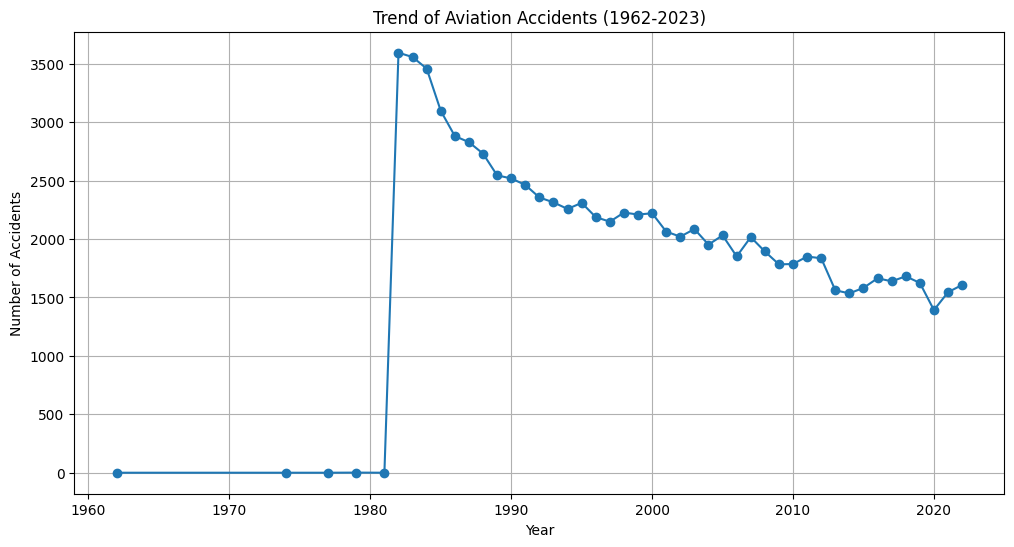

In [53]:


plt.figure(figsize=(12,6))
plt.plot(accidents_yearly.index, accidents_yearly.values, marker='o', linestyle='-')
plt.title("Trend of Aviation Accidents (1962-2023)")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.grid(True)
plt.show()

The accidents have been on a downward trend since 1982 when the highest accidents/incidents were recorded at 3593. This is good indication for the industry. It is also an indication that proper analysis of air craft accidents and incidents were done from 1982.

In [54]:
data_df.to_csv("AviationData.csv", index=False)

## Findings & Recommendations

1. Given the data provided and the analysis, the lowest risk make and models of air crafts are as follows:
    1. Zlin model Z143,Z-42M and Savage
    2. Zivkko aeronotics inc. mode Edde 540-T
    3. a. le francois model RANS S-7
    4. A. H. Gettings model GLASSAIR
    5. A pair of jacks model RV-6A

From the above findings, the company should invest in the above makes amd models as they have been involved in the fewest accidents. 

2. The air craft makes with the highest accidents are as follows:
    1. Cessna
    2. Piper
    3. Beech
    4. Boeing
    5. Bell

The above air craft makes are the ones that have been prone to accidents and incidents over the years. If the company feels that they would want to invest in any of the makes, then they should conduct further research.

3. The accidents trend of air craft have gradually declined over the years from 1982 to date. The year 2020 recorded the lowest accident but because it was the year with minimal air traffic due to the Covid19 pandemic. The decline in accidents signifies that the industry has put in place and worked on mitigating factors that lessen the occurrences of accidents and incidents.

4. The company is interested in operating both commercial and private enterprises of the industry. From the correlation analysis between 'purpose of flight' and 'total fatal injuries', it showed a very weak relationship between the two. I would recommend that they should operate both commercial and private.